<a href="https://colab.research.google.com/github/Lindaoctaviani7/Lindaoctaviani7-Machine-learning_Ganjil_TI3B_2026_244107020002/blob/main/TI3B_244107020002_Linda_Octaviani_Kuis1_ML_EDA_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



```
# This is formatted as code
```

# 📊 Kuis 1 Machine Learning - EDA & Preprocessing
Soal kuis berbasis dataset TI-3B. Buat dataset TI-3B dengan fitur sebagai berikut: nama lengkap, jenis kelamin, kota asal, tinggi badan(cm), asal kelas, target IP semester 5, warna kesukaan, hobi, film favorit, warna favorit, genre musik, idola, kota favorit, makanan favorit, minuman favorit, negara yang ingin dikunjungi.
Silakan kerjakan langsung di Colab dengan mengisi kode dan jawabanmu.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [29]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
file_path = "/content/drive/MyDrive/Data Saya/semester 5/pembelajaran mesin/Dataset TI-3B.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")

# Tampilkan 10 data awal
df.head(10)

,no,nama lengkap,jenis kelamin,kota asal,tinggi badan (cm),asal kelas,target IP smt 5,warna kesukaan,hobi,film fav,genre musik,idola,kota fav,makanan fav,minuman fav,negara yang ingin dikunjungi
0,1,Alfreda Dhaifullah Mahezwara,L,Malang,172,2C,4,Red Marron,Main ML,The Shadow Edge,Britpop,Jackable,"malang,batu",Nasi Goreng,Es Teler,China
1,2,Angga Saputra Ramadhan,L,Probolinggo,163,2B,4,Putih,Sepak Bola,Semua,Electropop,Neymar Jr,Malang,Ayam Geprek,Capuccino,Thailand
2,3,Ardhan Dikri Achmad Fahrudin,L,Malang,172,2H,4,Biru,Basket,Toy Story,Pop,Messi,Labuan Bajo,Tahu Telor,Hot V60,Swiss
3,4,Arjuna Carly Dhymas Mahendra,L,Sidoarjo,165,2B,4,Biru,Basket,Seven,Rock,Ronaldo,Bandung,Sate Ayam,Air Mineral,Swiss
4,5,Arya Ramadhan,L,Malang,175,2G,4,Ungu,Berenang,Lucifer (2016-2021)`,Pop,Diana Rider,Malang,Oyi Buttermilk,KAPITEN,UK
5,6,Ayu Annisa Aryani Nagari,P,Nganjuk,154,2E,4,marron,berenang,Spider-man,Pop indie,kim taehyung,yogyakarta,bakso,Air mineral,jepang
6,7,Bagus Wichaksono Amanulloh,L,Malang,178,2A,4,Biru,Otomotif,Cars 2,EDM,Kimi Antonelli,Bandung,Sate Ayam,Es Pisang Ijo,Australia
7,8,Burhanuddin Ihsan,L,Blitar,173,2B,4,Biru,mendengarkan kajian,opet the movie,Pop,Si madun,lucerne/luzern,Nasi Pecel,Air Mineral,Swiss
8,9,Daana Hafidhil Islam,L,Blitar,163,2B,4,Hitam,Mancing,Jatuh Cinta Seperti di Film-Film,Pop,Bernadya,Bandung,Mie Ayam,Air Mineral,Austria
9,10,Dewi Anggraini Meita Sari,P,Nganjuk,158,2C,4,Maroon,Menari,5 cm,Pop,Pearl Ocsh,Malang,Udang,Air Mineral,Jepang


## Soal 1
Hitung rata-rata tinggi badan mahasiswa **yang asal kotanya sama dengan kamu**.

- Bersihkan data asal kota dulu, jika ada data yang berisi "kota madiun", "kabupaten malang" bersihkan hingga hanya menjadi "madiun" dan "malang"
- Bandingkan tinggi badanmu dengan rata-rata kota asal.
- Apakah kamu lebih tinggi atau lebih rendah dari rata-rata tersebut?

In [ ]:
# Jawaban Soal 1
NAMA_SAYA = "Linda Octaviani"

# Bersihkan kolom "kota asal": hapus imbuhan "kota"/"kabupaten", samakan kapitalisasi
def clean_kota(x):
    x = str(x).strip().lower()
    for prefix in ["kota ", "kabupaten ", "kab. ", "kab "]:
        if x.startswith(prefix):
            x = x[len(prefix):]
    return x.strip().title()

df["kota asal_clean"] = df["kota asal"].apply(clean_kota)
print("Kota asal setelah dibersihkan:", sorted(df["kota asal_clean"].unique()))

# Cari data saya & kota asal saya
data_saya = df[df["nama lengkap"] == NAMA_SAYA].iloc[0]
tinggi_saya = data_saya["tinggi badan (cm)"]
kota_saya = data_saya["kota asal_clean"]
print(f"\nNama: {NAMA_SAYA} | Kota asal: {kota_saya} | Tinggi: {tinggi_saya} cm")

# Rata-rata tinggi badan mahasiswa dari kota asal yang sama
rata2_kota = df.groupby("kota asal_clean")["tinggi badan (cm)"].mean()
rata2_kota_saya = rata2_kota[kota_saya]
print(f"Rata-rata tinggi badan mahasiswa asal {kota_saya}: {rata2_kota_saya:.2f} cm")
print(df[df["kota asal_clean"] == kota_saya][["nama lengkap", "tinggi badan (cm)"]])


Kota asal setelah dibersihkan: ['Bali', 'Banyuwangi', 'Blitar', 'Bojonegoro', 'Bondowoso', 'Denpasar', 'Jakarta', 'Malang', 'Nganjuk', 'Pasuruan', 'Probolinggo', 'Sidoarjo', 'Tulungagung']

Nama: Linda Octaviani | Kota asal: Nganjuk | Tinggi: 155 cm
Rata-rata tinggi badan mahasiswa asal Nganjuk: 155.67 cm
                 nama lengkap  tinggi badan (cm)
5    Ayu Annisa Aryani Nagari                154
9   Dewi Anggraini Meita Sari                158
13            Linda Octaviani                155


In [ ]:
# Jawaban soal 1

if tinggi_saya > rata2_kota_saya:
    kesimpulan = "LEBIH TINGGI"
elif tinggi_saya < rata2_kota_saya:
    kesimpulan = "LEBIH RENDAH"
else:
    kesimpulan = "SAMA DENGAN"

print(f"Tinggi badan saya ({tinggi_saya} cm) {kesimpulan} dari rata-rata tinggi badan "
      f"mahasiswa asal {kota_saya} ({rata2_kota_saya:.2f} cm).")

#hasil: Untuk data saat ini (Linda Octaviani, asal Nganjuk)

Tinggi badan saya (155 cm) LEBIH RENDAH dari rata-rata tinggi badan mahasiswa asal Nganjuk (155.67 cm).


## Soal 2
Kolom **Target IP semester 5 ini** memiliki variasi format (angka, teks, koma/titik).

- Bersihkan kolom menjadi numerik.
- Lakukan normalisasi Min-Max.
- Berapa nilai normalisasi IPS target kamu sendiri?

In [ ]:
# Jawaban Soal 2
import re

# Bersihkan kolom "target IP smt 5" menjadi numerik
def clean_ip(x):
    s = str(x).strip().lower()
    s = re.sub(r"[^0-9,.\-]", "", s)      # buang huruf/karakter non-angka
    s = s.replace(",", ".")               # koma -> titik sebagai desimal
    if s.count(".") > 1:                  # jaga-jaga jika ada titik ganda (ribuan)
        parts = s.split(".")
        s = parts[0] + "." + "".join(parts[1:])
    try:
        return float(s)
    except ValueError:
        return np.nan

df["ip_clean"] = df["target IP smt 5"].apply(clean_ip)
print(df["ip_clean"].describe())

# Normalisasi Min-Max
ip_min = df["ip_clean"].min()
ip_max = df["ip_clean"].max()
print(f"\nIP minimum: {ip_min}, IP maksimum: {ip_max}")

if ip_max - ip_min == 0:
    # Semua nilai IP sama -> tidak ada rentang untuk dinormalisasi, hasilnya 0 untuk semua
    df["ip_normalized"] = 0.0
else:
    df["ip_normalized"] = (df["ip_clean"] - ip_min) / (ip_max - ip_min)

data_saya = df[df["nama lengkap"] == NAMA_SAYA].iloc[0]
ip_saya = data_saya["ip_clean"]
ip_norm_saya = data_saya["ip_normalized"]
print(f"\nTarget IP saya (bersih): {ip_saya}")
print(f"Nilai normalisasi Min-Max IP saya: {ip_norm_saya}")
#hasil
# Pada dataset ini, ternyata SEMUA mahasiswa punya target IP semester 5 yang sama, yaitu 4
# (setelah dibersihkan menjadi numerik: 4.0 untuk seluruh 25 data).
# Karena nilai minimum = nilai maksimum (4.0), rentang (max - min) = 0,
# sehingga rumus normalisasi Min-Max (x - min) / (max - min) menjadi tidak terdefinisi (pembagian dengan 0).
# Dalam kasus ini kita anggap hasil normalisasinya 0.0 untuk semua data (karena tidak ada variasi sama sekali).
# Jadi, nilai normalisasi IPS target saya = 0.0
# (bukan karena IP saya rendah, tapi karena seluruh angkatan menargetkan IP yang sama persis).

count    25.0
mean      4.0
std       0.0
min       4.0
25%       4.0
50%       4.0
75%       4.0
max       4.0
Name: ip_clean, dtype: float64

IP minimum: 4.0, IP maksimum: 4.0

Target IP saya (bersih): 4.0
Nilai normalisasi Min-Max IP saya: 0.0


## Soal 3
Lakukan **Label Encoding** pada kolom **Warna kesukaan**.

- Tampilkan hasil encoding warna kesukaanmu sendiri.
- Apakah warnamu termasuk kode terkecil, terbesar, atau di tengah?

In [ ]:
# Jawaban Soal 3
from sklearn.preprocessing import LabelEncoder

# Samakan format teks dulu (huruf kecil, tanpa spasi berlebih) agar warna yang sama tidak dianggap beda
df["warna_clean"] = df["warna kesukaan"].str.strip().str.lower()

le = LabelEncoder()
df["warna_encoded"] = le.fit_transform(df["warna_clean"])

mapping = dict(zip(le.classes_, le.transform(le.classes_)))
jumlah_pemilih = df["warna_clean"].value_counts()

print("Mapping Label Encoding warna kesukaan:")
for warna, kode in mapping.items():
    print(f"  {warna:<12} -> kode {kode:<2} | dipilih oleh {jumlah_pemilih[warna]} orang")

data_saya = df[df["nama lengkap"] == NAMA_SAYA].iloc[0]
warna_saya = data_saya["warna_clean"]
kode_saya = data_saya["warna_encoded"]
kode_min = df["warna_encoded"].min()
kode_max = df["warna_encoded"].max()

print(f"\nWarna kesukaan saya: {warna_saya} -> kode: {kode_saya}")
print(f"Rentang kode: {kode_min} (terkecil) s.d. {kode_max} (terbesar)")
#Hasil
# Bagi rentang kode menjadi 3 bagian (kecil / tengah / besar) untuk menilai posisi kode saya
rentang = kode_max - kode_min
batas_bawah_kode = kode_min + rentang / 3
batas_atas_kode = kode_max - rentang / 3

if kode_saya == kode_min:
    posisi = "KODE TERKECIL (paling minimum)"
elif kode_saya == kode_max:
    posisi = "KODE TERBESAR (paling maksimum)"
elif kode_saya <= batas_bawah_kode:
    posisi = "kelompok kode KECIL (dekat minimum)"
elif kode_saya >= batas_atas_kode:
    posisi = "kelompok kode BESAR (dekat maksimum)"
else:
    posisi = "kelompok kode TENGAH"
print(f"Kode warna saya ({kode_saya}) termasuk {posisi} dari seluruh kode warna kesukaan (rentang {kode_min}-{kode_max}).")

Mapping Label Encoding warna kesukaan:
  abu          -> kode 0  | dipilih oleh 1 orang
  biru         -> kode 1  | dipilih oleh 9 orang
  biru tua     -> kode 2  | dipilih oleh 1 orang
  hitam        -> kode 3  | dipilih oleh 2 orang
  kuning       -> kode 4  | dipilih oleh 1 orang
  maroon       -> kode 5  | dipilih oleh 2 orang
  marron       -> kode 6  | dipilih oleh 1 orang
  merah muda   -> kode 7  | dipilih oleh 1 orang
  pink         -> kode 8  | dipilih oleh 1 orang
  putih        -> kode 9  | dipilih oleh 4 orang
  red marron   -> kode 10 | dipilih oleh 1 orang
  ungu         -> kode 11 | dipilih oleh 1 orang

Warna kesukaan saya: biru -> kode: 1
Rentang kode: 0 (terkecil) s.d. 11 (terbesar)
Kode warna saya (1) termasuk kelompok kode KECIL (dekat minimum) dari seluruh kode warna kesukaan (rentang 0-11).


## Soal 4
Kelompokkan data berdasarkan **Jenis kelamin**.

- Hitung rata-rata tinggi badan tiap kelompok.
- Bandingkan tinggi badanmu dengan rata-rata kelompokmu.

In [ ]:
# Jawaban Soal 4

# Kelompokkan berdasarkan jenis kelamin, hitung rata-rata tinggi badan tiap kelompok
rata2_gender = df.groupby("jenis kelamin")["tinggi badan (cm)"].mean()

rata2_L = rata2_gender["L"]
rata2_P = rata2_gender["P"]
print("Rata-rata tinggi badan tiap kelompok jenis kelamin:")
print(f"  Laki-laki (L)  : {rata2_L:.2f} cm  (n = {(df['jenis kelamin']=='L').sum()} orang)")
print(f"  Perempuan (P)  : {rata2_P:.2f} cm  (n = {(df['jenis kelamin']=='P').sum()} orang)")

data_saya = df[df["nama lengkap"] == NAMA_SAYA].iloc[0]
gender_saya = data_saya["jenis kelamin"]
tinggi_saya = data_saya["tinggi badan (cm)"]
rata2_gender_saya = rata2_gender[gender_saya]

print(f"\nJenis kelamin saya: {gender_saya} | Tinggi saya: {tinggi_saya} cm")
print(f"Rata-rata tinggi kelompok saya ({gender_saya}): {rata2_gender_saya:.2f} cm")
#Hasil
if tinggi_saya > rata2_gender_saya:
    kesimpulan = "LEBIH TINGGI"
elif tinggi_saya < rata2_gender_saya:
    kesimpulan = "LEBIH RENDAH"
else:
    kesimpulan = "SAMA DENGAN"

print(f"Tinggi badan saya ({tinggi_saya} cm) {kesimpulan} rata-rata tinggi kelompok "
      f"{gender_saya} ({rata2_gender_saya:.2f} cm).")

Rata-rata tinggi badan tiap kelompok jenis kelamin:
  Laki-laki (L)  : 171.89 cm  (n = 18 orang)
  Perempuan (P)  : 157.86 cm  (n = 7 orang)

Jenis kelamin saya: P | Tinggi saya: 155 cm
Rata-rata tinggi kelompok saya (P): 157.86 cm
Tinggi badan saya (155 cm) LEBIH RENDAH rata-rata tinggi kelompok P (157.86 cm).


## Soal 5 (pilih 2 fitur dari fitur yang ada)
Selanjutnya buat bar chart distribusi (misal)**Makanan favorit dan minuman favorit**.

- Dari grafik tersebut, apakah makanan dan minuman favoritmu termasuk dominan atau minoritas?

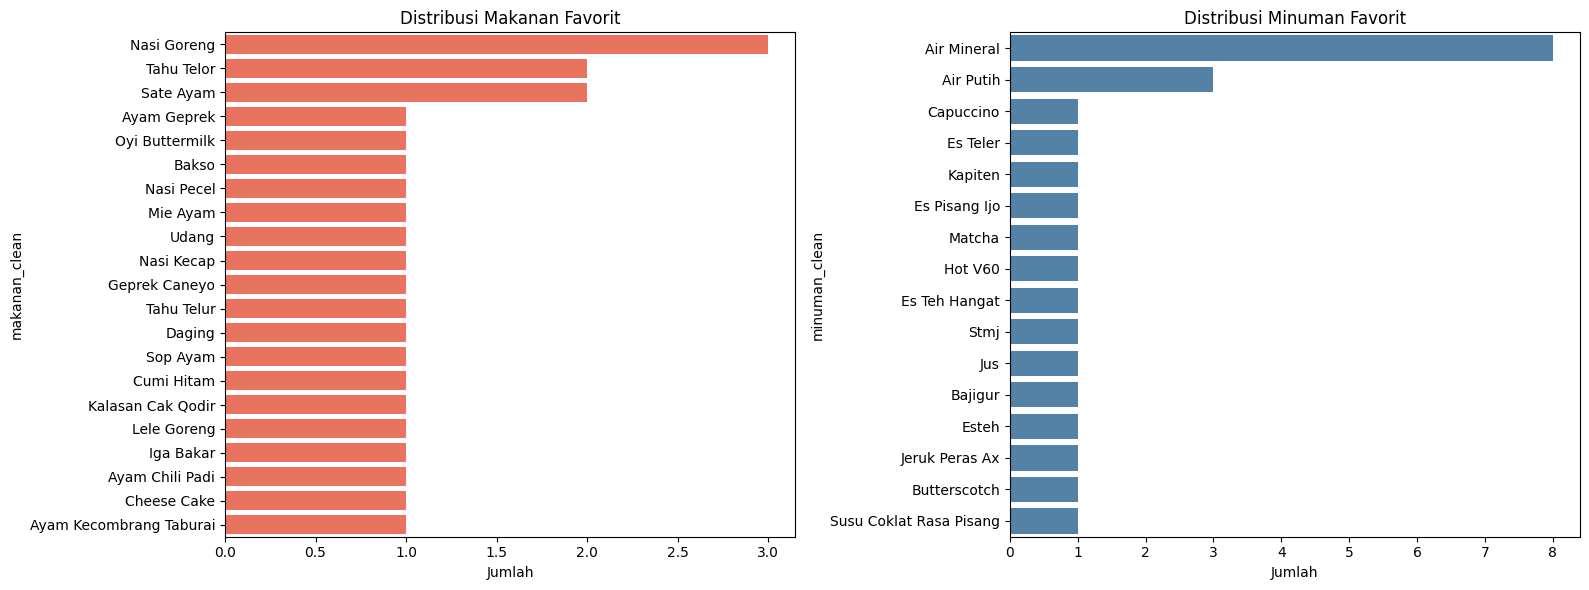

Makanan favorit saya: Geprek Caneyo (dipilih 1 orang, dari total 25)
Minuman favorit saya: Air Mineral (dipilih 8 orang, dari total 25)
Makanan favorit saya (Geprek Caneyo) termasuk MINORITAS pada grafik.
Minuman favorit saya (Air Mineral) termasuk DOMINAN pada grafik.


In [ ]:
# Jawaban Soal 5
# Fitur yang dipilih adalah makanan favorit dan minuman favorit

# Samakan kapitalisasi dulu supaya nama yang sama tidak terhitung dobel (misal "Air Mineral" vs "Air mineral")
df["makanan_clean"] = df["makanan fav"].str.strip().str.title()
df["minuman_clean"] = df["minuman fav"].str.strip().str.title()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

makanan_counts = df["makanan_clean"].value_counts()
sns.barplot(x=makanan_counts.values, y=makanan_counts.index, ax=axes[0], color="tomato")
axes[0].set_title("Distribusi Makanan Favorit")
axes[0].set_xlabel("Jumlah")

minuman_counts = df["minuman_clean"].value_counts()
sns.barplot(x=minuman_counts.values, y=minuman_counts.index, ax=axes[1], color="steelblue")
axes[1].set_title("Distribusi Minuman Favorit")
axes[1].set_xlabel("Jumlah")

plt.tight_layout()
plt.show()

data_saya = df[df["nama lengkap"] == NAMA_SAYA].iloc[0]
makanan_saya = data_saya["makanan_clean"]
minuman_saya = data_saya["minuman_clean"]
jml_makanan_saya = makanan_counts[makanan_saya]
jml_minuman_saya = minuman_counts[minuman_saya]

print(f"Makanan favorit saya: {makanan_saya} (dipilih {jml_makanan_saya} orang, dari total {len(df)})")
print(f"Minuman favorit saya: {minuman_saya} (dipilih {jml_minuman_saya} orang, dari total {len(df)})")
#Hasil
def status(jml, counts):
    return "DOMINAN" if jml == counts.max() else "MINORITAS"

status_makanan = status(jml_makanan_saya, makanan_counts)
status_minuman = status(jml_minuman_saya, minuman_counts)
print(f"Makanan favorit saya ({makanan_saya}) termasuk {status_makanan} pada grafik.")
print(f"Minuman favorit saya ({minuman_saya}) termasuk {status_minuman} pada grafik.")

## Soal 6
Gunakan metode **IQR (Interquartile Range)** untuk mendeteksi outlier tinggi badan.

- Apakah tinggi badanmu termasuk outlier atau tidak?

In [28]:
# Jawaban Soal 6

# Hitung Q1, Q3, dan IQR untuk kolom tinggi badan
Q1 = df["tinggi badan (cm)"].quantile(0.25)
Q3 = df["tinggi badan (cm)"].quantile(0.75)
IQR = Q3 - Q1

batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

print(f"Q1 = {Q1}, Q3 = {Q3}, IQR = {IQR}")
print(f"Batas bawah = {batas_bawah}, Batas atas = {batas_atas}")

outliers = df[(df["tinggi badan (cm)"] < batas_bawah) | (df["tinggi badan (cm)"] > batas_atas)]
print(f"\nJumlah outlier terdeteksi: {len(outliers)}")
print(outliers[["nama lengkap", "tinggi badan (cm)"]])

data_saya = df[df["nama lengkap"] == NAMA_SAYA].iloc[0]
tinggi_saya = data_saya["tinggi badan (cm)"]
is_outlier = (tinggi_saya < batas_bawah) or (tinggi_saya > batas_atas)
print(f"\nTinggi badan saya: {tinggi_saya} cm")
#Hasil
print(f"Apakah tinggi badan saya termasuk outlier? {'YA' if is_outlier else 'TIDAK'}")

Q1 = 160.0, Q3 = 175.0, IQR = 15.0
Batas bawah = 137.5, Batas atas = 197.5

Jumlah outlier terdeteksi: 0
Empty DataFrame
Columns: [nama lengkap, tinggi badan (cm)]
Index: []

Tinggi badan saya: 155 cm
Apakah tinggi badan saya termasuk outlier? TIDAK


## Soal 7
Bersihkan kolom **Asal kelas** (hapus spasi berlebih, seragamkan huruf kapitalisasi).

- Hitung jumlah mahasiswa per kelas.
- Apakah kamu termasuk di kelas dengan jumlah terbanyak, menengah, atau sedikit?

In [ ]:
# Jawaban Soal 7

# Bersihkan kolom "asal kelas": hapus spasi berlebih, seragamkan huruf kapital
df["asal kelas_clean"] = df["asal kelas"].str.strip().str.upper()

jumlah_per_kelas = df["asal kelas_clean"].value_counts().sort_values(ascending=False)
print("Jumlah mahasiswa per kelas:")
print(jumlah_per_kelas)

data_saya = df[df["nama lengkap"] == NAMA_SAYA].iloc[0]
kelas_saya = data_saya["asal kelas_clean"]
jml_kelas_saya = jumlah_per_kelas[kelas_saya]
print(f"\nKelas saya: {kelas_saya} | Jumlah anggota kelas ini: {jml_kelas_saya}")
#Hasil
kelas_terbanyak = jumlah_per_kelas.idxmax()
kelas_tersedikit = jumlah_per_kelas.idxmin()

if kelas_saya == kelas_terbanyak:
    posisi = "kelas dengan jumlah TERBANYAK"
elif kelas_saya == kelas_tersedikit:
    posisi = "kelas dengan jumlah TERSEDIKIT"
else:
    posisi = "kelas dengan jumlah MENENGAH"

print(f"Kelas saya ({kelas_saya}, {jml_kelas_saya} orang) termasuk {posisi}.")

Jumlah mahasiswa per kelas:
asal kelas_clean
2B    7
2C    6
2A    4
2G    3
2H    2
2F    2
2E    1
Name: count, dtype: int64

Kelas saya: 2A | Jumlah anggota kelas ini: 4
Kelas saya (2A, 4 orang) termasuk kelas dengan jumlah MENENGAH.
